In [73]:
import pandas as pd

df = pd.DataFrame({
    "Voltage": [400,400,400,132],
    "Power":   [2494,4988,7482,237],
    "Cost":    [2.081,2.489,3.202,1.646]
})



In [74]:
import numpy as np
from scipy.interpolate import griddata

# Extract arrays
X = df["Voltage"].values
Y = df["Power"].values
Z = df["Cost"].values

# High‑resolution grid
xi = np.linspace(66, max(X), 500)
yi = np.linspace(min(Y), max(Y), 500)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolation
Zi_lin = griddata((X, Y), Z, (Xi, Yi), method='linear')
Zi_near = griddata((X, Y), Z, (Xi, Yi), method='nearest')
Zi = np.where(np.isnan(Zi_lin), Zi_near, Zi_lin)

# Optional smoothing
from scipy.ndimage import gaussian_filter
Zi = gaussian_filter(Zi, sigma=1.2)

# Plot
surf = ax.plot_surface(
    Xi, Yi, Zi,
    cmap='viridis',
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=True,
    alpha=0.85
)




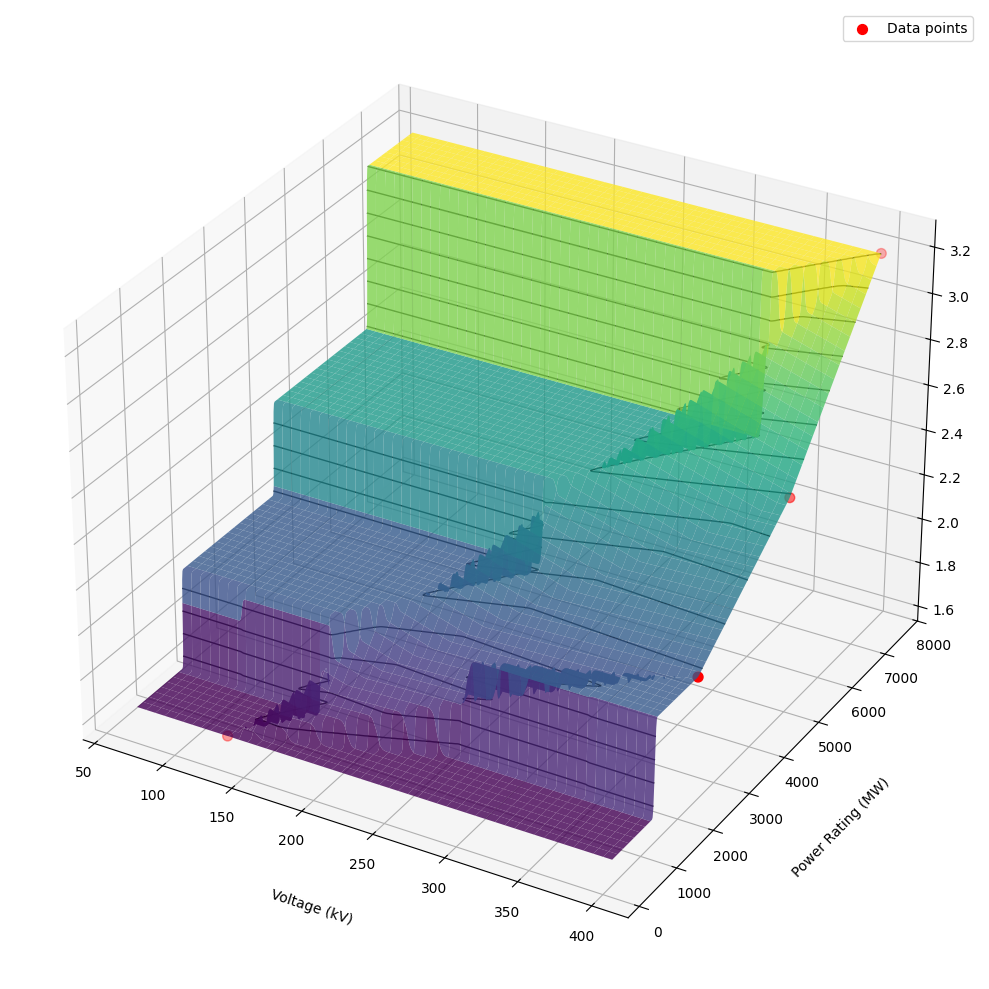

done


In [75]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Plot
fig = plt.figure(figsize=(16,10))
ax = fig.add_subplot(111, projection='3d')

# Surface
surf = ax.plot_surface(Xi, Yi, Zi, cmap='viridis', alpha=0.8)

# Raw data points
ax.scatter(X, Y, Z, color='red', s=50, label='Data points')

ax.set_xlabel("Voltage (kV)")
ax.set_ylabel("Power Rating (MW)")
ax.set_zlabel("Build Cost (£m/km)")
ax.contour(Xi, Yi, Zi, 
           levels=15, 
           linewidths=1, 
           colors='black', 
           offset=None)

#ax.view_init(elev=90, azim=0)
ax.legend()
ax.set_xlabel("Voltage (kV)", labelpad=20)
ax.set_ylabel("Power Rating (MW)", labelpad=20)
ax.set_zlabel("Build Cost (£m/km)", labelpad=20)

fig.subplots_adjust(left=0.15, bottom=0.15)
plt.tight_layout(pad=3)

plt.tight_layout()
plt.show()


print("done")

Predicted cost of 200mw 1.974673236537537 £M/km


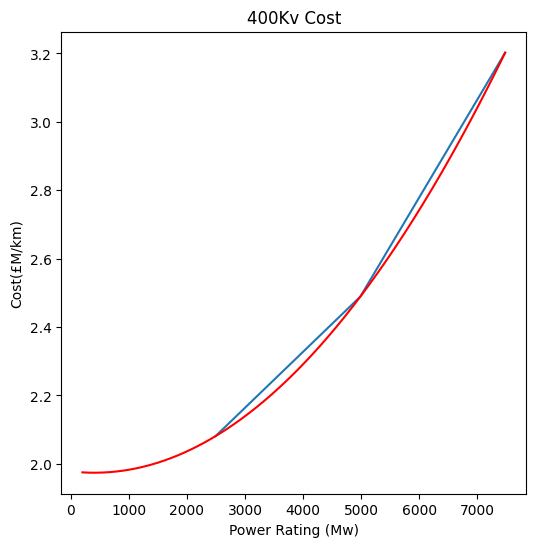

In [82]:
import matplotlib.pyplot as plt
import numpy as np

Voltage = [400,400,400]
Power =   [2494,4988,7482]
Cost = [2.081,2.489,3.202]

# Convert lists → numpy arrays
Power = np.array(Power)
Cost  = np.array(Cost)

coeffs = np.polyfit(Power, Cost, 2)
poly = np.poly1d(coeffs)
# Generate smooth x-values for plotting the curve
x_line = np.linspace(200, Power.max(), 500)
y_line = poly(x_line)

predicted_cost = poly(237)
print("Predicted cost of 200mw", predicted_cost, "£M/km")

plt.figure(figsize=(6, 6))
plt.plot(Power,Cost)
plt.plot(x_line, y_line, color="red", label="Polynomial fit")
plt.xlabel("Power Rating (Mw)")
plt.ylabel("Cost(£M/km)")
plt.title("400Kv Cost")
plt.show()

Predicted cost of 200mw 1.7760746268656722 £M/km


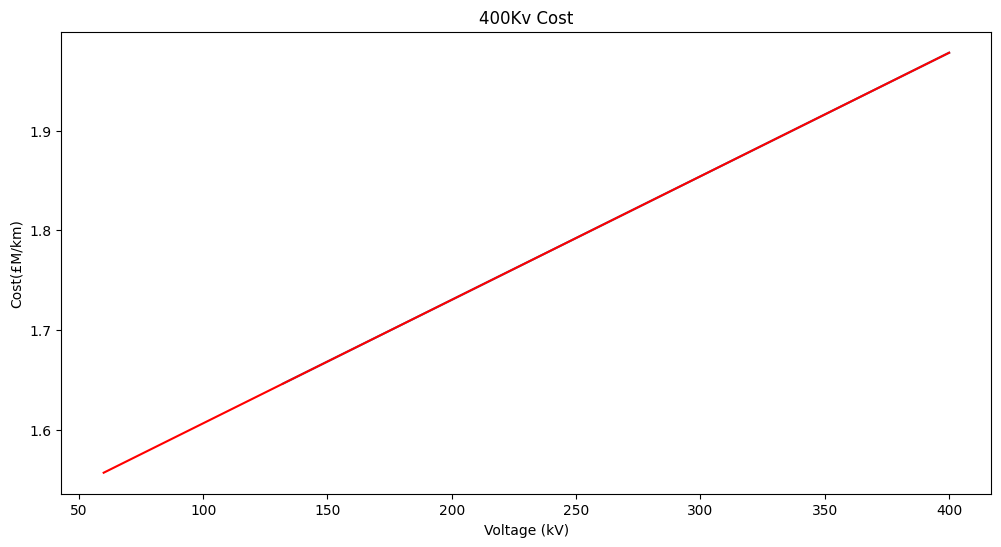

In [89]:
import matplotlib.pyplot as plt
import numpy as np

Voltage = [132,400]
Power =   [237,237]
Cost = [1.646,1.978]

# Convert lists → numpy arrays
Voltage = np.array(Voltage)
Power = np.array(Power)
Cost  = np.array(Cost)

coeffs = np.polyfit(Voltage, Cost, 1)
poly = np.poly1d(coeffs)
# Generate smooth x-values for plotting the curve
x_line = np.linspace(60, Voltage.max(), 500)
y_line = poly(x_line)

predicted_cost = poly(237)
print("Predicted cost of 200mw", predicted_cost, "£M/km")

plt.figure(figsize=(12, 6))
plt.plot(Voltage,Cost)
plt.plot(x_line, y_line, color="red", label="Polynomial fit")
plt.xlabel("Voltage (kV)")
plt.ylabel("Cost(£M/km)")
plt.title("400Kv Cost")
plt.show()